Embeddings : (2078, 32)
Labels     : (2078, 5)  (5 classes)
Train/Val/Test split: 1246 / 415 / 417
k=2  HL=0.3137  F1=0.3613  t=0.4s
k=3  HL=0.2873  F1=0.3634  t=0.4s
k=4  HL=0.3012  F1=0.3403  t=0.4s


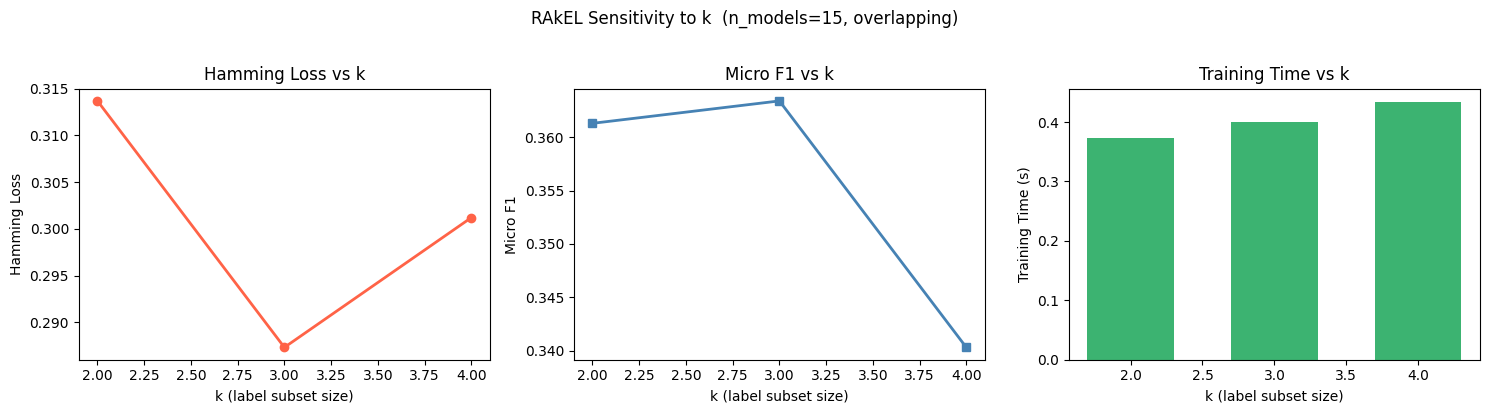

n_models=  2  HL=0.3295  F1=0.3324
n_models=  5  HL=0.3108  F1=0.3696
n_models= 10  HL=0.3218  F1=0.3804
n_models= 15  HL=0.2873  F1=0.3634
n_models= 20  HL=0.2863  F1=0.3642
n_models= 30  HL=0.2825  F1=0.3673
n_models= 40  HL=0.2844  F1=0.3658


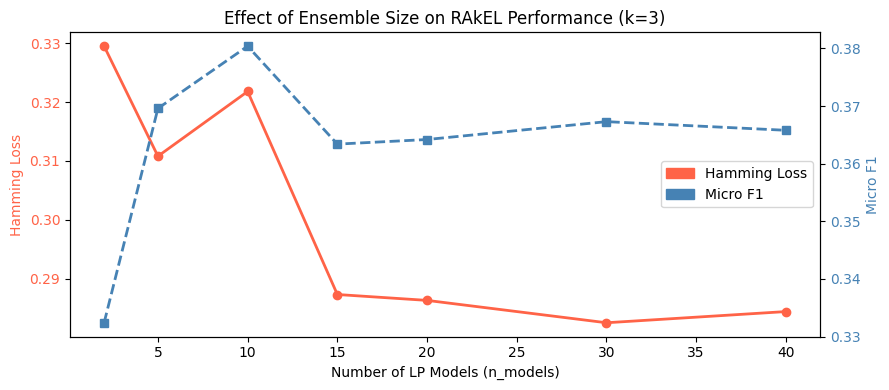

RAkEL + Decision Tree           MicroF1=0.3634  HL=0.2806  t=1.3s
RAkEL + SVM                     MicroF1=0.4167  HL=0.2484  t=4.0s
RAkEL + Logistic Regression     MicroF1=0.4348  HL=0.2494  t=1.1s


,accuracy,f1_micro,f1_macro,precision,recall,support_pos
CAD,0.7890,0.3973,0.6347,0.4677,0.3452,84
CKD,0.7362,0.1538,0.4988,0.4167,0.0943,106
DMT2,0.8082,0.2000,0.5455,0.4762,0.1266,79
Healthy,0.6043,0.6224,0.6034,0.5292,0.7556,180
OST,0.8201,0.0000,0.4506,0.0000,0.0000,75


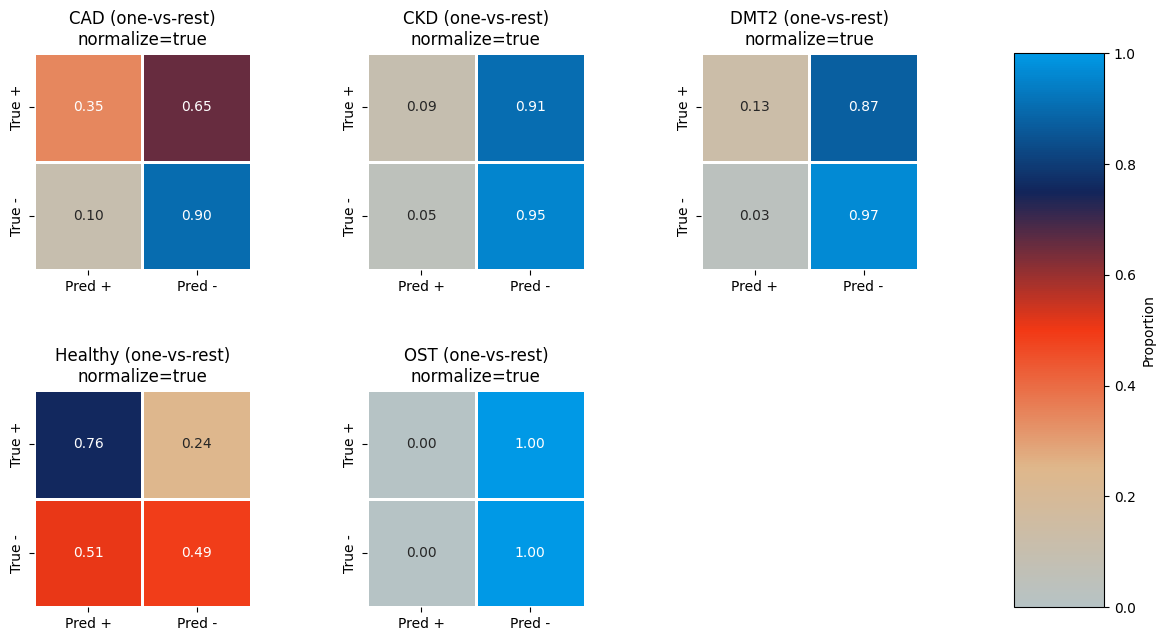

In [9]:
# ============================================================
# RAkEL Analysis on GNN Embeddings — YEAST Dataset
# ============================================================
# Loads pre-computed GNN embeddings, then benchmarks RAkEL across:
#   1. Sensitivity to label subset size k
#   2. Effect of ensemble size (n_models)
#   3. Comparison of base classifiers
# ============================================================

import pickle
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from time import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

sys.path.insert(0, "./../MAIN/")
from applications import RAkEL, plot_per_class_confusion_matrices
from train import evaluate_multilabel, per_class_metrics_from_scores

# ── Config ────────────────────────────────────────────────────────────────────
PKL_PATH   = "/work/gr-fe/bryan/MOGSage/results/Final/mogsage_gnn_embeddings_0.2.pkl"
K_DEFAULT  = 3          # label subset size used outside the k-sweep
N_MODELS_DEFAULT = 15   # ensemble size used outside the n_models-sweep
THRESHOLD  = 0.5
RANDOM_STATE = 42

# ── 1. Load embeddings ────────────────────────────────────────────────────────
with open(PKL_PATH, "rb") as f:
    blob = pickle.load(f)

H         = blob["embeddings"]          # (N, d)
train_idx = blob["train_idx"]
val_idx   = blob["val_idx"]
test_idx  = blob["test_idx"]
y         = blob["y"].astype(int)       # (N, C) multi-hot
n_labels  = y.shape[1]

print(f"Embeddings : {H.shape}")
print(f"Labels     : {y.shape}  ({n_labels} classes)")
print(f"Train/Val/Test split: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

# ── 2. Build train / test sets (train + val → fit, test → evaluate) ───────────
fit_idx = np.concatenate([train_idx, val_idx])
X_train, y_train = H[fit_idx],    y[fit_idx]
X_test,  y_test  = H[test_idx],   y[test_idx]

# ── Helper ────────────────────────────────────────────────────────────────────
def run_rakel(k, n_models, base_clf, X_tr=X_train, y_tr=y_train,
              X_te=X_test, y_te=y_test, mode="overlapping"):
    """Fit a RAkEL model and return (metrics_dict, elapsed_seconds)."""
    model = RAkEL(k=k, n_models=n_models, base_clf=base_clf,
                  mode=mode, threshold=THRESHOLD)
    t0 = time()
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    elapsed = time() - t0
    metrics = evaluate_multilabel(y_te, y_pred)
    return metrics, elapsed, y_pred

# ── 3. Sweep k ────────────────────────────────────────────────────────────────
k_range = range(2, min(8, n_labels))
k_results = []

for k in k_range:
    m, t, _ = run_rakel(k, N_MODELS_DEFAULT,
                     DecisionTreeClassifier(random_state=RANDOM_STATE))
    k_results.append({"k": k, "Hamming Loss": m["Hamming Loss"],
                       "Micro F1": m["Micro F1"], "Time (s)": t})
    print(f"k={k}  HL={m['Hamming Loss']:.4f}  F1={m['Micro F1']:.4f}  t={t:.1f}s")

df_k = pd.DataFrame(k_results).set_index("k")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_k.index, df_k["Hamming Loss"], "o-", color="tomato",     lw=2)
axes[1].plot(df_k.index, df_k["Micro F1"],     "s-", color="steelblue",  lw=2)
axes[2].bar(df_k.index,  df_k["Time (s)"],          color="mediumseagreen", width=0.6)
for ax, ylabel, title in zip(
    axes,
    ["Hamming Loss", "Micro F1", "Training Time (s)"],
    ["Hamming Loss vs k", "Micro F1 vs k", "Training Time vs k"]
):
    ax.set_xlabel("k (label subset size)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
fig.suptitle(
    f"RAkEL Sensitivity to k  (n_models={N_MODELS_DEFAULT}, overlapping)",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# ── 4. Sweep n_models ─────────────────────────────────────────────────────────
n_model_range = [2, 5, 10, 15, 20, 30, 40]
nm_results = []

for n_m in n_model_range:
    m, _, _ = run_rakel(K_DEFAULT, n_m,
                     DecisionTreeClassifier(random_state=RANDOM_STATE))
    nm_results.append({"n_models": n_m, "Hamming Loss": m["Hamming Loss"],
                        "Micro F1": m["Micro F1"]})
    print(f"n_models={n_m:3d}  HL={m['Hamming Loss']:.4f}  F1={m['Micro F1']:.4f}")

df_nm = pd.DataFrame(nm_results).set_index("n_models")

fig, ax1 = plt.subplots(figsize=(9, 4))
color1, color2 = "tomato", "steelblue"
ax1.plot(df_nm.index, df_nm["Hamming Loss"], "o-", color=color1, lw=2)
ax1.set_xlabel("Number of LP Models (n_models)")
ax1.set_ylabel("Hamming Loss", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(df_nm.index, df_nm["Micro F1"], "s--", color=color2, lw=2)
ax2.set_ylabel("Micro F1", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title(f"Effect of Ensemble Size on RAkEL Performance (k={K_DEFAULT})")
plt.legend(
    handles=[mpatches.Patch(color=c, label=l)
             for c, l in [(color1, "Hamming Loss"), (color2, "Micro F1")]],
    loc="center right"
)
plt.tight_layout()
plt.show()

# ── 5. Compare base classifiers ───────────────────────────────────────────────
base_clfs = {
    "Decision Tree"      : DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM"                : SVC(decision_function_shape="ovo",  random_state=RANDOM_STATE),
    "Logistic Regression": LogisticRegression(max_iter=500, solver="lbfgs"),
}

clf_results = []
y_pred = []
for name, clf in base_clfs.items():
    m, t, y_pred_tmp = run_rakel(k=3, n_models=50, base_clf=clf)
    y_pred.append(y_pred_tmp)
    m["Model"]    = f"RAkEL + {name}"
    m["Time (s)"] = round(t, 3)
    clf_results.append(m)
    print(f"RAkEL + {name:<22s}  MicroF1={m['Micro F1']:.4f}  HL={m['Hamming Loss']:.4f}  t={t:.1f}s")

(
    pd.DataFrame(clf_results)
    .set_index("Model")
    .style
    .background_gradient(subset=["Micro F1", "Sample F1"], cmap="Greens")
    .background_gradient(subset=["Hamming Loss"],           cmap="Reds_r")
    .format(precision=4)
    .set_caption("RAkEL with Different Base Classifiers (k=7, n_models=50)")
)

best_res = per_class_metrics_from_scores(
    y_pred[pd.DataFrame(clf_results)['Hamming Loss'].idxmin()] , 
    y_test
)

df_res = pd.DataFrame(best_res['per_class'])
df_res.index = blob['label_names']

styler = (
    df_res
    .style
    .background_gradient(subset=["accuracy", "f1_micro", "f1_macro", "precision"], cmap="Greens")
    .format(precision=4)
    .set_caption("Per Class Metrics")
)
display(styler)
styler.to_html("./../../results/Figures/per_class_metrics.html")

fig, axes = plot_per_class_confusion_matrices(best_res , class_labels=blob['label_names'])
fig.savefig("./../../results/Figures/per_class_confusion_matrices.svg", format="svg", bbox_inches="tight")